# DETECCION DE PERSONAS CON HOG Y SVM
### https://www.kaggle.com/datasets/constantinwerner/human-detection-dataset

# Se cargan las bibliotecas necesarias

In [1]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import cv2
from skimage.feature import hog

# Se importan los dos datasets 
### https://docs.python.org/3/library/glob.html

In [2]:
import glob
person = glob.glob("archive/human detection dataset/1/*.png") #Se actualizan rutas de dataset de personas
no_person = glob.glob("archive/human detection dataset/0/*.png") #Se actualizan rutas de dataset de no personas
#Ahora el modelo carga imágenes de personas y no personas del dataset de detección humana. Es necesario porque las clases ya no son vehículo/no vehículo.

In [3]:
len(person)

1108

In [4]:
len(no_person)

1235

# Se muestra una imagen con vehículo

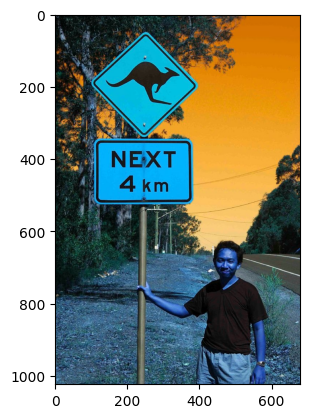

In [5]:
img_color = cv2.imread(person[10])
plt.imshow(img_color)

# Para fines de demostración se calcula el HOG de la imagen

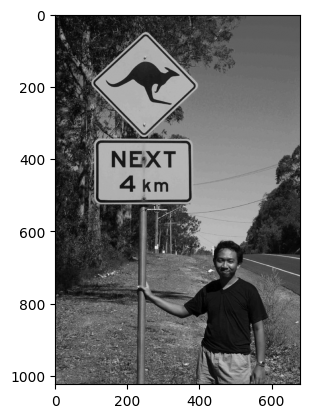

In [6]:
img_gray = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray,cmap="gray")

In [7]:
features,hog_img = hog(img_gray,
                       orientations = 11,
                       pixels_per_cell = (16,16),
                       cells_per_block = (2,2),
                       transform_sqrt = False,
                       visualize = True,
                       feature_vector = True)

In [8]:
features.shape

(113652,)

In [9]:
hog_img.shape

(1024, 680)

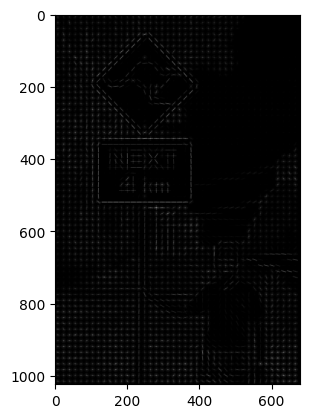

In [10]:
plt.imshow(hog_img,cmap = 'gray')

# Se extraen las features del HOG para ambos tipos de datos

De la siguiente función, se cambian variables y parametros de vehicle -> a person
e actualiza la variable para acumular características HOG de imágenes con peatones.

In [11]:
person_hog_accum = []

target_size = (64, 128)  # ancho, alto típico para detección de peatones con HOG

for i in person:
    img_color = cv2.imread(i) #Se hizo el cambio porque algunas imágenes no podían leerse correctamente con mpimg.imread. OpenCV es más estable para cargar imágenes en tareas de visión computacional.

    if img_color is None:
        print(f"No se pudo cargar: {i}")
        continue

    img_color = cv2.resize(img_color, target_size) #Este cambio es muy importante. En detección de peatones, HOG normalmente trabaja con ventanas de 64x128. Además, evita errores porque todas las imágenes deben generar vectores HOG del mismo tamaño.
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    person_hog_feature, person_hog_img = hog(img_gray,
                                                orientations=11,
                                                pixels_per_cell=(16,16),
                                                cells_per_block=(2,2),
                                                transform_sqrt=False,
                                                visualize=True,
                                                feature_vector=True
    )

    person_hog_accum.append(person_hog_feature)

Ahora la clase positiva 1 representa “persona/peatón”, no vehículo.

In [12]:
X_person = np.vstack(person_hog_accum).astype(np.float64)
y_person = np.ones(len(X_person))

In [13]:
X_person.shape

(1108, 924)

In [14]:
y_person.shape

(1108,)

Se adapta la extracción HOG para la clase negativa: imágenes sin personas.
Es necesario aplicar exactamente el mismo preprocesamiento a ambas clases para que el modelo compare características consistentes.

In [15]:
noperson_hog_accum = []

target_size = (64, 128)  # ancho, alto

for i in no_person:

    img_color = cv2.imread(i)
    # Verificar que la imagen cargó correctamente
    if img_color is None:
        print(f"No se pudo cargar: {i}")
        continue
    
    img_color = cv2.resize(img_color, target_size) # Redimensionar imagen
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    noperson_hog_feature, noperson_hog_img = hog(
        img_gray,
        orientations=11,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        transform_sqrt=False,
        visualize=True,
        feature_vector=True
    )

    noperson_hog_accum.append(noperson_hog_feature)

La clase negativa 0 ahora significa “no persona”.

In [16]:
X_noperson = np.vstack(noperson_hog_accum).astype(np.float64) #Se construye el dataset final para clasificación binaria: persona vs no persona.
y_noperson = np.zeros(len(X_noperson)) #Se construye el dataset final para clasificación binaria: persona vs no persona.

In [17]:
X_noperson.shape

(1235, 924)

In [18]:
y_noperson.shape

(1235,)

# Se combinan ambos tipos de datos para alimentar el SVM

In [19]:
X = np.vstack((X_person,X_noperson))
X.shape

(2343, 924)

In [20]:
y = np.hstack((y_person,y_noperson))
y.shape

(2343,)

# Se generan los datos de entrenamiento y de prueba

Se agrego stratify=y. Mantiene la misma proporción de personas/no personas en train y test, evitando particiones desbalanceadas.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y, random_state = 42) #Stratify Y

In [22]:
X_train.shape

(1640, 924)

In [23]:
X_test.shape

(703, 924)

# Se importa el Clasificador y se entrena

Se agregó 'class_weight' para penalizar más los errores sobre la clase persona. En detección de peatones, reducir falsos negativos es importante porque no detectar una persona es más crítico.

In [24]:
#from sklearn.svm import LinearSVC

#svc_model = LinearSVC()
#svc_model.fit(X_train, y_train)
from sklearn.svm import SVC

svc_model = SVC(class_weight={0: 1, 1: 3}) # más peso a persona
svc_model.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.","{0: 1, 1: 3}"
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
y_predict = svc_model.predict(X_test)

<Axes: >

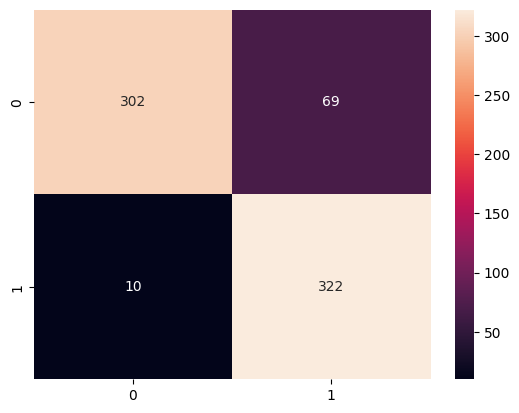

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test,y_predict)
sns.heatmap(cm, annot=True, fmt = "d")

In [27]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

         0.0       0.97      0.81      0.88       371
         1.0       0.82      0.97      0.89       332

    accuracy                           0.89       703
   macro avg       0.90      0.89      0.89       703
weighted avg       0.90      0.89      0.89       703



# GridSearchCV

Se agrega otro kernel para comparar resultados (linear)
Se reduce C de [0.1, 1, 10, 100, 1000] a [0.1, 1, 10]. Para evitar sobreajustes y perdida de tiempo en la corrida del codigo

In [28]:
param_grid = {'C': [0.1,1, 10], "class_weight": [{0: 1, 1: 3}],'gamma': [1,0.1,0.01,0.001,0.0001], 'kernel': ['linear', 'rbf'],} 

Se agrega class_weight al grid. Permite buscar un modelo más sensible a peatones. Sin embargo, usar solo {0:1, 1:3} puede sesgarlo demasiado hacia clase 1.

Se agrega scoring="f1" en GridSearchCV. f1 balancea precision y recall.

In [29]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(SVC(),param_grid,scoring= "f1", refit=True,verbose=4)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END C=0.1, class_weight={0: 1, 1: 3}, gamma=1, kernel=linear;, score=0.867 total time=   0.1s
[CV 2/5] END C=0.1, class_weight={0: 1, 1: 3}, gamma=1, kernel=linear;, score=0.858 total time=   0.2s
[CV 3/5] END C=0.1, class_weight={0: 1, 1: 3}, gamma=1, kernel=linear;, score=0.856 total time=   0.1s
[CV 4/5] END C=0.1, class_weight={0: 1, 1: 3}, gamma=1, kernel=linear;, score=0.834 total time=   0.1s
[CV 5/5] END C=0.1, class_weight={0: 1, 1: 3}, gamma=1, kernel=linear;, score=0.840 total time=   0.1s
[CV 1/5] END C=0.1, class_weight={0: 1, 1: 3}, gamma=1, kernel=rbf;, score=0.642 total time=   0.7s
[CV 2/5] END C=0.1, class_weight={0: 1, 1: 3}, gamma=1, kernel=rbf;, score=0.642 total time=   0.5s
[CV 3/5] END C=0.1, class_weight={0: 1, 1: 3}, gamma=1, kernel=rbf;, score=0.642 total time=   0.5s
[CV 4/5] END C=0.1, class_weight={0: 1, 1: 3}, gamma=1, kernel=rbf;, score=0.642 total time=   0.5s
[CV 5/5] END C=0.1, cla

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'class_weight': [{0: 1, 1: 3}], 'gamma': [1, 0.1, ...], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sco

In [30]:
grid.best_params_

{'C': 1, 'class_weight': {0: 1, 1: 3}, 'gamma': 0.1, 'kernel': 'rbf'}

In [31]:
grid.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.","{0: 1, 1: 3}"
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [32]:
grid_predictions = grid.predict(X_test)

<Axes: >

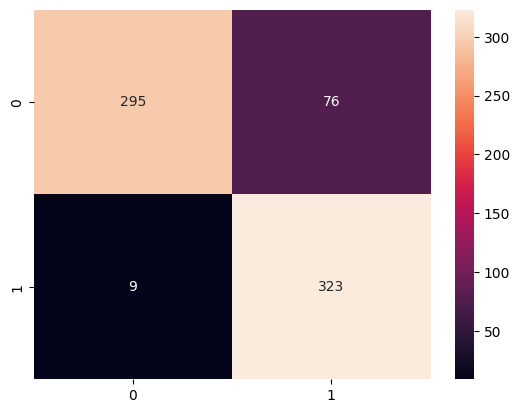

In [33]:
cm = confusion_matrix(y_test,grid_predictions)
sns.heatmap(cm, annot=True, fmt = "d")

In [34]:
print(classification_report(y_test,grid_predictions))

              precision    recall  f1-score   support

         0.0       0.97      0.80      0.87       371
         1.0       0.81      0.97      0.88       332

    accuracy                           0.88       703
   macro avg       0.89      0.88      0.88       703
weighted avg       0.89      0.88      0.88       703

